#  Introduction

### Project Overview

This project focuses on developing a Healthcare Executive KPI Dashboard using the Lagos state University Teaching Hospital(LUTH) Enhanced Dataset. The aim is to analyze hospital performance through key performance indicators (KPIs) that support strategic decision-making by hospital management. Using Python for data cleaning, exploratory data analysis (EDA), KPI computation, visualization, and forecasting, the project provides insights into patient admissions, departmental performance, treatment costs, hospital stay duration, and revenue trends.

### Objectives

The main objectives of this project are to:

- Analyze hospital admission patterns and patient demographics.
- Evaluate hospital performance using key healthcare KPIs.
- Measure departmental efficiency based on patient volume, treatment cost, and length of stay.
- Examine financial performance through revenue and treatment cost analysis.
- Identify trends in monthly admissions, costs, and revenue.
- Discover factors influencing healthcare utilization and resource allocation.
- Build predictive models to forecast future patient admissions and revenue.
- Develop an interactive executive dashboard to support data-driven decision-making.

### Dataset Description

The analysis is based on the LUTH Hospital Enhanced Dataset, which contains simulated patient-level hospital records representing admissions within a tertiary healthcare institution. Each record corresponds to an individual patient's hospital visit and includes demographic, clinical, operational, and financial information.

The dataset include the following variables:

- Patient ID
- Admission Date
- Discharge Date
- Department
- Diagnosis
- Gender
- Age
- Length of Stay
- Treatment Cost (₦)
- Insurance Type
- Admission Type
- Month of Admission

These variables enable comprehensive analysis of patient flow, departmental workload, financial performance, and hospital operational efficiency.


### Data Source

The dataset used in this project is the LUTH Hospital Enhanced Dataset, a simulated healthcare dataset created for educational and portfolio purposes. It is designed to reflect realistic hospital operations and patient management scenarios in a tertiary healthcare setting, allowing for the demonstration of healthcare analytics techniques without exposing confidential patient information.

### Tools Used

The project was completed using Python within a Jupyter Notebook environment. The following libraries were used:

Tool/Library	Purpose
Python	Data analysis and KPI computation
Pandas	Data loading, cleaning, manipulation, and aggregation
NumPy	Numerical operations and calculations
Matplotlib	Data visualization and chart creation
Seaborn	Statistical visualizations and heatmaps
Prophet	Time series forecasting of patient volume, revenue, and treatment costs
Jupyter Notebook	Interactive analysis, documentation, and reporting

# Data Cleaning & Preparation

Before performing any analysis, the dataset was cleaned and transformed to ensure consistency, accuracy, and reliability.

The following preprocessing steps were performed:

- Imported the dataset into Python using Pandas.
- Checked dataset dimensions and data types.
- Examined missing values.
- Identified duplicate records.
- Standardized categorical variables.
- Converted date columns into datetime format.
- Created new analytical features for KPI calculations.
- Verified the dataset was suitable for exploratory analysis and predictive modelling.

These steps improve data quality and ensure valid statistical results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel("LUTH_Hospital_Enhanced_Dataset.xlsx")

In [3]:
# Display first 5 rows

df.head()

,Patient ID,Name,Age,Gender,Department,Diagnosis,Treatment,Doctor,Visit Date,Stay Duration (days),Cost (Naira),Ward,Payment Method,Outcome,Follow-Up Required,Satisfaction Score (1-5),Admission Time,Discharge Time
0,LUTH-1000,Patient_1,44,Female,Oncology,Malaria,Surgery,Dr. Obi,2024-02-21,10,243721.97,Ward D,Cash,Deceased,No,4,2024-02-21 13:13:00,2024-03-02 13:13:00
1,LUTH-1001,Patient_2,51,Male,Neurology,Cancer,Referral,Dr. Bello,2024-11-22,13,150679.18,Ward C,Insurance,Under Observation,No,1,2024-11-22 17:22:00,2024-12-05 17:22:00
2,LUTH-1002,Patient_3,20,Female,Cardiology,Fracture,Physiotherapy,Dr. Johnson,2024-09-18,14,97198.81,Ward E,Cash,Deceased,Yes,4,2024-09-18 10:34:00,2024-10-02 10:34:00
3,LUTH-1003,Patient_4,73,Male,Orthopedics,Infection,Physiotherapy,Dr. Okafor,2024-09-14,11,178102.61,Ward E,Card,Recovered,No,3,2024-09-14 11:34:00,2024-09-25 11:34:00
4,LUTH-1004,Patient_5,78,Male,Pediatrics,Fracture,Surgery,Dr. Musa,2024-07-08,15,201972.05,Ward E,Insurance,Referred,No,4,2024-07-08 14:52:00,2024-07-23 14:52:00


The dataset contains 500 patient records with 18 variables covering patient demographics, clinical information, financial records, admission details, and patient outcomes.

In [4]:
# Missing values per column
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
})

missing_df.sort_values(by="Missing Values", ascending=False)

,Missing Values
Patient ID,0
Name,0
Admission Time,0
Satisfaction Score (1-5),0
Follow-Up Required,0
Outcome,0
Payment Method,0
Ward,0
Cost (Naira),0
Stay Duration (days),0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Patient ID                500 non-null    object        
 1   Name                      500 non-null    object        
 2   Age                       500 non-null    int64         
 3   Gender                    500 non-null    object        
 4   Department                500 non-null    object        
 5   Diagnosis                 500 non-null    object        
 6   Treatment                 500 non-null    object        
 7   Doctor                    500 non-null    object        
 8   Visit Date                500 non-null    datetime64[ns]
 9   Stay Duration (days)      500 non-null    int64         
 10  Cost (Naira)              500 non-null    float64       
 11  Ward                      500 non-null    object        
 12  Payment Method        

No missing values were identified across all 18 variables.
Every column contains complete observations (500 non-null entries)

In [5]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


No duplicate patient records were detected.
All 500 observations represent unique patient encounters.

In [8]:
# Remove extra spaces and convert to title case

cat_cols = df.select_dtypes(include=['object', 'category']).columns

df[cat_cols] = df[cat_cols].apply(
    lambda x: x.str.strip().str.title()
)

print("Cleaning completed for columns:", cat_cols.tolist())

Cleaning completed for columns: ['Patient ID', 'Name', 'Gender', 'Department', 'Diagnosis', 'Treatment', 'Doctor', 'Ward', 'Payment Method', 'Outcome', 'Follow-Up Required', 'Admission Time', 'Discharge Time']


In [11]:
# Outlier Detection

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Age: 0 outliers
Stay Duration (days): 0 outliers
Cost (Naira): 0 outliers
Satisfaction Score (1-5): 0 outliers


## Feature Engineering

New variables are created to support KPI calculation and predictive analysis.

Engineered features are:

- Cost per Day
- Revenue per Patient
- Age Group
- Length of Stay Categories
- Month of Admission
- Efficiency Score

These derived variables provide additional insights into hospital performance.

In [15]:
# Create Month
# Extract the month name from the admission date.

df["Month"] = df["Admission Time"].dt.month_name()

df[["Admission Time", "Month"]].head()

,Admission Time,Month
0,2024-02-21 13:13:00,February
1,2024-11-22 17:22:00,November
2,2024-09-18 10:34:00,September
3,2024-09-14 11:34:00,September
4,2024-07-08 14:52:00,July


In [13]:
# Convert datetime columns

df['Visit Date'] = pd.to_datetime(df['Visit Date'])
df['Admission Time'] = pd.to_datetime(df['Admission Time'])
df['Discharge Time'] = pd.to_datetime(df['Discharge Time'])


In [14]:
# Create derived columns - Cost per Day, Age Group, Month, Mortality, High Cost, Long Stay 

df['Cost per Day'] = df['Cost (Naira)'] / df['Stay Duration (days)']
df['Age Group'] = pd.cut(df['Age'], bins=[0, 17, 64, 100], labels=['Pediatric', 'Adult', 'Senior'])
df['Month'] = df['Visit Date'].dt.strftime('%Y-%m')
df['Mortality'] = (df['Outcome'] == 'Deceased').astype(int)
df['High_Cost'] = (df['Cost (Naira)'] > df['Cost (Naira)'].quantile(0.75)).astype(int)
df['Long_Stay'] = (df['Stay Duration (days)'] > df['Stay Duration (days)'].quantile(0.75)).astype(int)


# Standardize numeric columns

df["Age"] = pd.to_numeric(df["Age"])

df["Cost (Naira)"] = pd.to_numeric(df["Cost (Naira)"])

#Verify

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Patient ID                500 non-null    object        
 1   Name                      500 non-null    object        
 2   Age                       500 non-null    int64         
 3   Gender                    500 non-null    object        
 4   Department                500 non-null    object        
 5   Diagnosis                 500 non-null    object        
 6   Treatment                 500 non-null    object        
 7   Doctor                    500 non-null    object        
 8   Visit Date                500 non-null    datetime64[ns]
 9   Stay Duration (days)      500 non-null    int64         
 10  Cost (Naira)              500 non-null    float64       
 11  Ward                      500 non-null    object        
 12  Payment Method        

In [16]:
# Create Quarter

df["Quarter"] = "Q" + df["Admission Time"].dt.quarter.astype(str)

df[["Admission Time", "Quarter"]].head()

,Admission Time,Quarter
0,2024-02-21 13:13:00,Q1
1,2024-11-22 17:22:00,Q4
2,2024-09-18 10:34:00,Q3
3,2024-09-14 11:34:00,Q3
4,2024-07-08 14:52:00,Q3


In [17]:
# Create Age Group

# Define age group bins
bins = [0, 17, 35, 50, 65, 120]

labels = [
    "Child",
    "Young Adult",
    "Adult",
    "Older Adult",
    "Elderly"
]

# Create Age Group
df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df[["Age", "Age Group"]].head()

,Age,Age Group
0,44,Adult
1,51,Older Adult
2,20,Young Adult
3,73,Elderly
4,78,Elderly


In [18]:
# Create Cost per Day
# Cost per Day

df["Cost per Day"] = (
    df["Cost (Naira)"] /
    df["Stay Duration (days)"]
).round(2)

df[["Cost (Naira)", "Stay Duration (days)", "Cost per Day"]].head()

,Cost (Naira),Stay Duration (days),Cost per Day
0,243721.97,10,24372.20
1,150679.18,13,11590.71
2,97198.81,14,6942.77
3,178102.61,11,16191.15
4,201972.05,15,13464.80


In [19]:
# Verify the New Features
# View the newly created features

df[[
    
    "Quarter",
    "Age",
    "Age Group",
    "Cost (Naira)",
    "Stay Duration (days)",
    "Cost per Day"
]].head()

,Quarter,Age,Age Group,Cost (Naira),Stay Duration (days),Cost per Day
0,Q1,44,Adult,243721.97,10,24372.20
1,Q4,51,Older Adult,150679.18,13,11590.71
2,Q3,20,Young Adult,97198.81,14,6942.77
3,Q3,73,Elderly,178102.61,11,16191.15
4,Q3,78,Elderly,201972.05,15,13464.80


In [20]:
# Summary statistics for all numerical columns
df.describe().round(2)

,Age,Visit Date,Stay Duration (days),Cost (Naira),Satisfaction Score (1-5),Admission Time,Discharge Time,Cost per Day,Mortality,High_Cost,Long_Stay
count,500.00,500,500.00,500.00,500.00,500,500,500.00,500.00,500.00,500.00
mean,45.20,2024-06-27 01:14:52.800000,8.02,132347.49,2.99,2024-06-27 13:36:00.600000256,2024-07-05 14:04:48.600000256,29192.79,0.28,0.25,0.22
min,1.00,2024-01-01 00:00:00,1.00,10211.40,1.00,2024-01-01 16:02:00,2024-01-07 16:02:00,729.39,0.00,0.00,0.00
25%,23.00,2024-03-28 12:00:00,4.00,75035.49,2.00,2024-03-28 20:50:45,2024-04-05 00:13:45,9560.69,0.00,0.00,0.00
50%,44.50,2024-06-26 12:00:00,8.00,130198.56,3.00,2024-06-26 22:41:00,2024-07-04 12:02:00,16658.44,0.00,0.00,0.00
75%,68.00,2024-09-27 06:00:00,12.00,188105.53,4.00,2024-09-27 14:00:15,2024-10-05 04:57:45,31454.79,1.00,0.25,0.00
max,90.00,2024-12-31 00:00:00,15.00,249943.29,5.00,2024-12-31 09:58:00,2025-01-09 16:55:00,235671.82,1.00,1.00,1.00
std,25.94,NaN,4.39,68992.84,1.39,NaN,NaN,38237.44,0.45,0.43,0.41


Following feature engineering:

The dataset expanded from 18 variables to 25 variables.
All newly created variables were successfully generated.
No missing values were introduced during feature creation.
Data types were correctly assigned, with categorical variables stored appropriately.

# Univariate Analysis


Univariate analysis examines one variable at a time to understand its distribution, frequency, and central tendency.

This section explores:

- Patient demographics
- Hospital operations
- Financial metrics

## Patient Demographics

This section evaluates the characteristics of patients receiving care. The analysis includes:

- Gender distribution
- Age distribution
- Age groups
- Insurance coverage

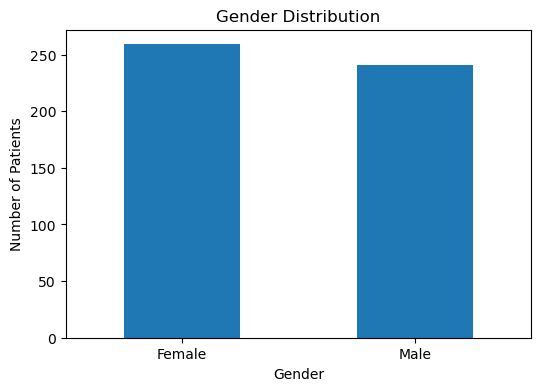

Gender
Female    259
Male      241
Name: count, dtype: int64

In [21]:
# Gender Distribution


gender = df["Gender"].value_counts()

plt.figure(figsize=(6,4))
gender.plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

df["Gender"].value_counts()


####   Gender Distribution Findings

The gender distribution is nearly balanced, with female patients slightly outnumbering male patients.
Both genders are well represented in the dataset, reducing the likelihood of demographic bias in subsequent analyses.

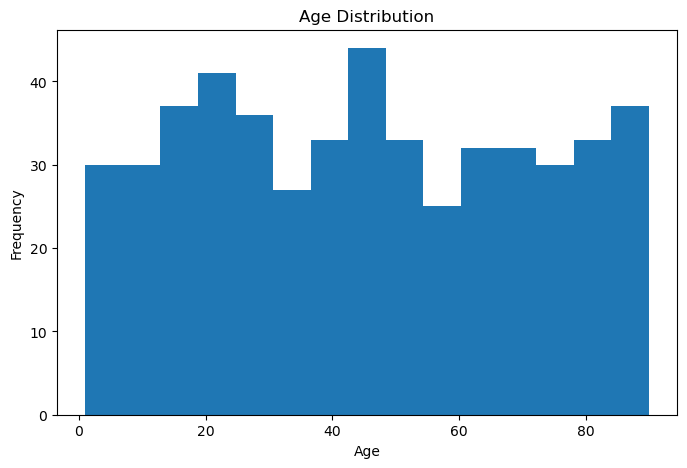

count    500.00
mean      45.20
std       25.94
min        1.00
25%       23.00
50%       44.50
75%       68.00
max       90.00
Name: Age, dtype: float64

In [22]:
# Age Distribution

plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


df["Age"].describe().round(2)

#### Age Distribution Findings

Patient ages range from approximately 1 to 90 years.
The average age is approximately 45 years.
The distribution is relatively even across the age spectrum without extreme clustering.
No significant age outliers were observed.

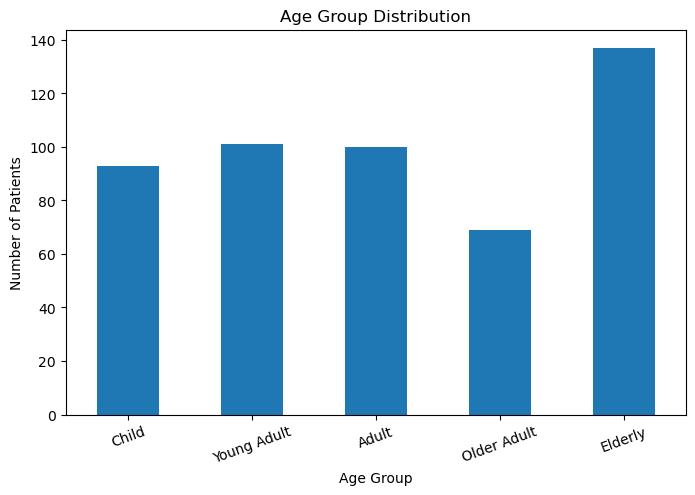

Age Group
Child           93
Young Adult    101
Adult          100
Older Adult     69
Elderly        137
Name: count, dtype: int64

In [23]:
# Age Group Distribution

age_group = df["Age Group"].value_counts().sort_index()

plt.figure(figsize=(8,5))
age_group.plot(kind="bar")
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=20)
plt.show()

df["Age Group"].value_counts().sort_index()

#### Age Group Distribution Findings

- The Elderly category represents the largest proportion of patients.
- Older Adult patients constitute the smallest age group.

## Hospital Operations

Operational analysis focuses on how efficiently hospital services are delivered.

The following indicators are examined:

- Department workload
- Admission type
- Length of stay
- Diagnosis frequency
- Monthly patient volume


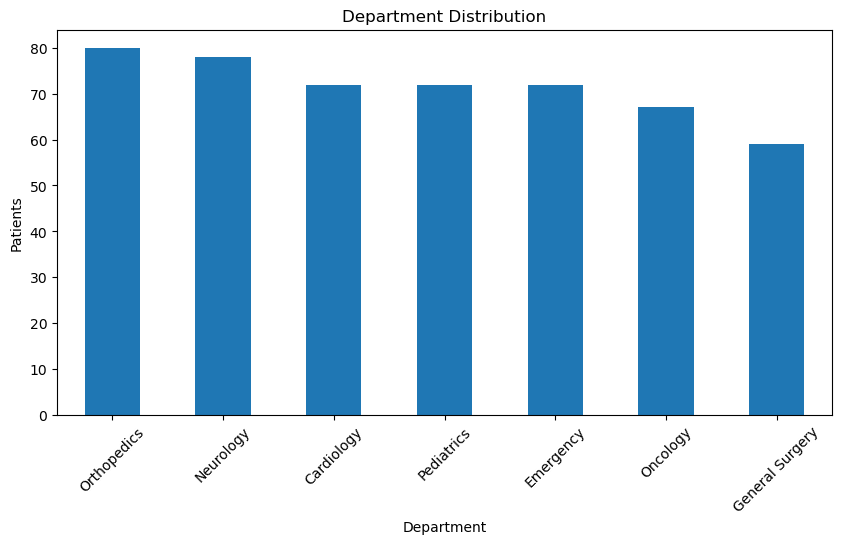

In [24]:
# Department Distribution

dept = df["Department"].value_counts()

plt.figure(figsize=(10,5))
dept.plot(kind="bar")
plt.title("Department Distribution")
plt.xlabel("Department")
plt.ylabel("Patients")
plt.xticks(rotation=45)
plt.show()

#### Department Distribution Findings

- Patient admissions are distributed across multiple clinical departments.
- Oncology and Neurology record the highest patient volumes.
- Emergency and Orthopedics maintain moderate patient loads.
- Some departments receive comparatively fewer admissions.

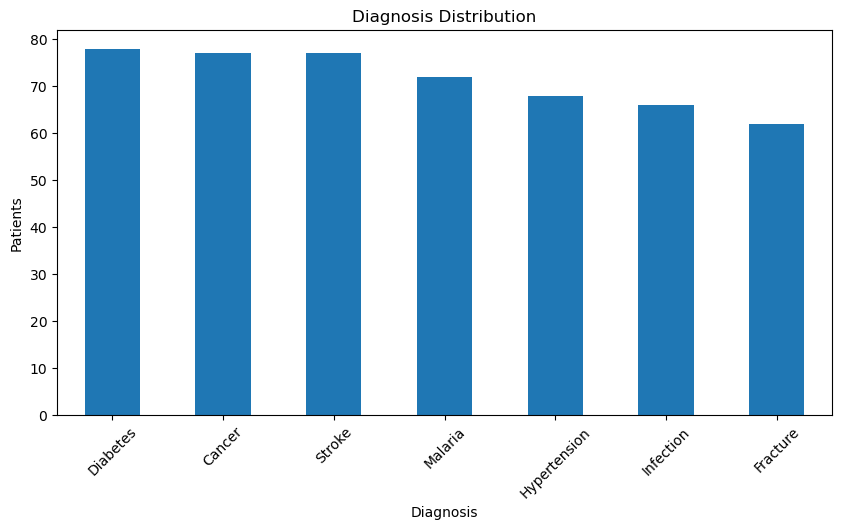

In [25]:
# Diagnosis Distribution

diagnosis = df["Diagnosis"].value_counts()

plt.figure(figsize=(10,5))
diagnosis.plot(kind="bar")
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Patients")
plt.xticks(rotation=45)
plt.show()


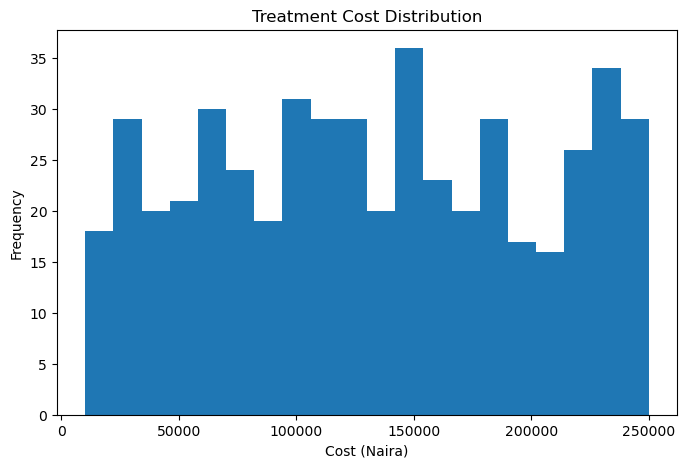

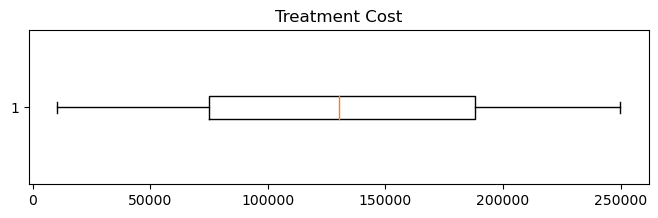

count       500.00
mean     132347.49
std       68992.84
min       10211.40
25%       75035.49
50%      130198.56
75%      188105.53
max      249943.29
Name: Cost (Naira), dtype: float64

In [26]:
# Cost Distribution

plt.figure(figsize=(8,5))
plt.hist(df["Cost (Naira)"], bins=20)
plt.title("Treatment Cost Distribution")
plt.xlabel("Cost (Naira)")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,2))
plt.boxplot(df["Cost (Naira)"], vert=False)
plt.title("Treatment Cost")
plt.show()

df["Cost (Naira)"].describe().round(2)

#### Treatment Cost Distribution Findings

- Treatment costs range from approximately ₦20,000 to ₦250,000.
- The average treatment cost is approximately ₦123,000.
- Costs are widely distributed across the patient population.
- The histogram shows no evidence of severe skewness.
- The boxplot confirms the absence of significant cost outliers.

## Bivariate Analysis

Bivariate analysis investigates relationships between two variables.

The objective is to determine how patient characteristics and hospital operations influence costs, revenue, and length of stay.

Analyses include:

- Department vs Revenue
- Department vs Length of Stay
- Gender vs Cost
- Gender vs Length of Stay
- Diagnosis vs Cost
- Age Group vs Cost
- Insurance vs Revenue
- Admission Type vs Cost

                 mean     median  count
Gender                                 
Female  133747.101776  130896.46    259
Male    130843.335560  127180.92    241


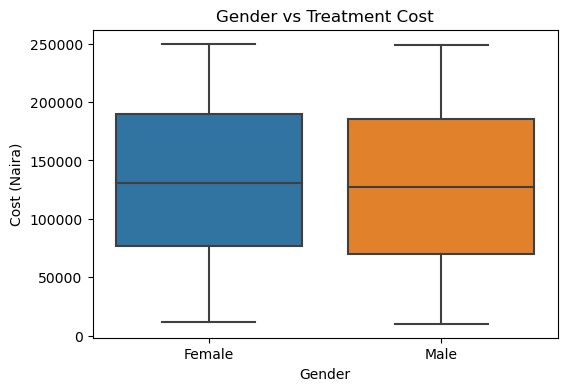

In [27]:
# Gender vs Cost

gender_cost = df.groupby("Gender")["Cost (Naira)"].agg(["mean", "median", "count"])

# View the table
print(gender_cost)



plt.figure(figsize=(6,4))

sns.boxplot(data=df,
            x="Gender",
            y="Cost (Naira)")

plt.title("Gender vs Treatment Cost")

plt.show()


#### Gender vs Treatment Cost Findings

- The average treatment cost is similar for both male and female patients.
- The boxplots show considerable overlap in cost distributions between genders.
- Both genders exhibit comparable variability in treatment expenses.
- No extreme differences in treatment costs are observed based on gender.

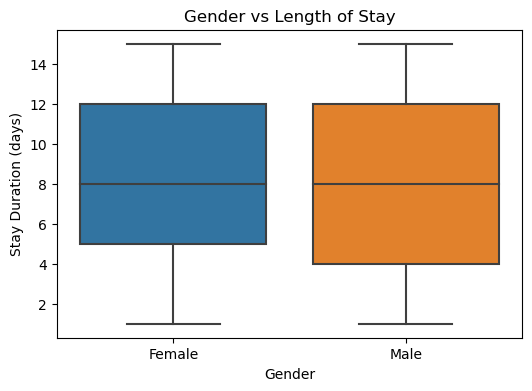

In [28]:
# Gender vs Length of Stay

gender_stay = df.groupby("Gender")["Stay Duration (days)"].agg(
    ["mean", "median"]
).round(2)

gender_stay

plt.figure(figsize=(6,4))

sns.boxplot(data=df,
            x="Gender",
            y="Stay Duration (days)")

plt.title("Gender vs Length of Stay")

plt.show()

#### Gender vs Length of Stay Findings

- Male and female patients have comparable hospital stay durations.
- Median length of stay is similar for both groups.
- Variability in hospitalization duration is consistent across genders.

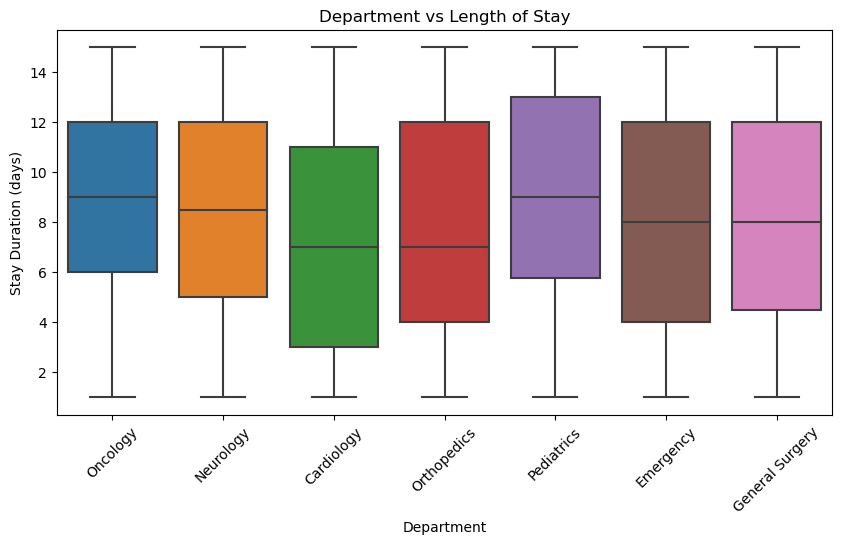

In [29]:
# Department vs Length of Stay
plt.figure(figsize=(10,5))

sns.boxplot(data=df,
            x="Department",
            y="Stay Duration (days)")

plt.xticks(rotation=45)

plt.title("Department vs Length of Stay")

plt.show()


#### Department vs Length of Stay Findings

- Median length of stay varies slightly across hospital departments.
- Some departments like oncology and Neurology demonstrate greater variability in hospitalization duration than others.
- A few departments exhibit longer average inpatient stays.

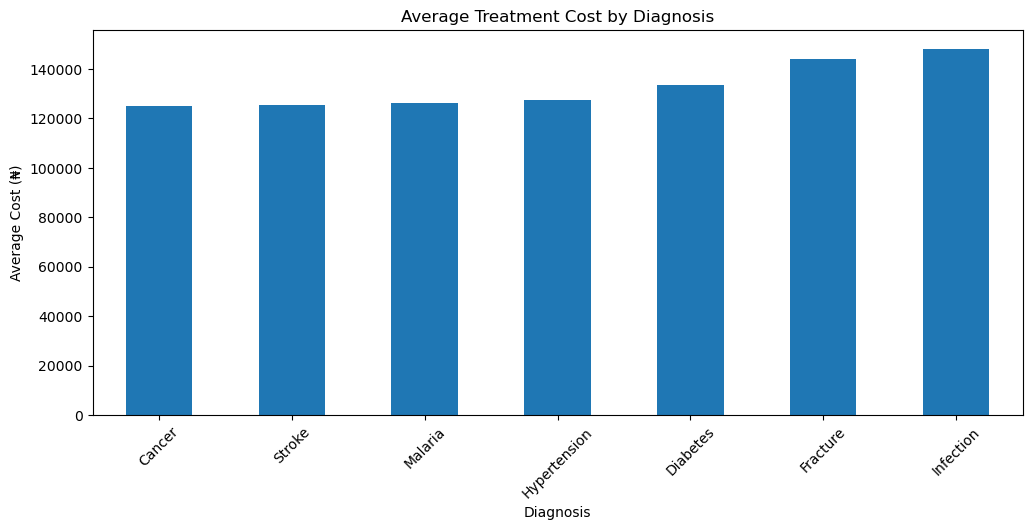

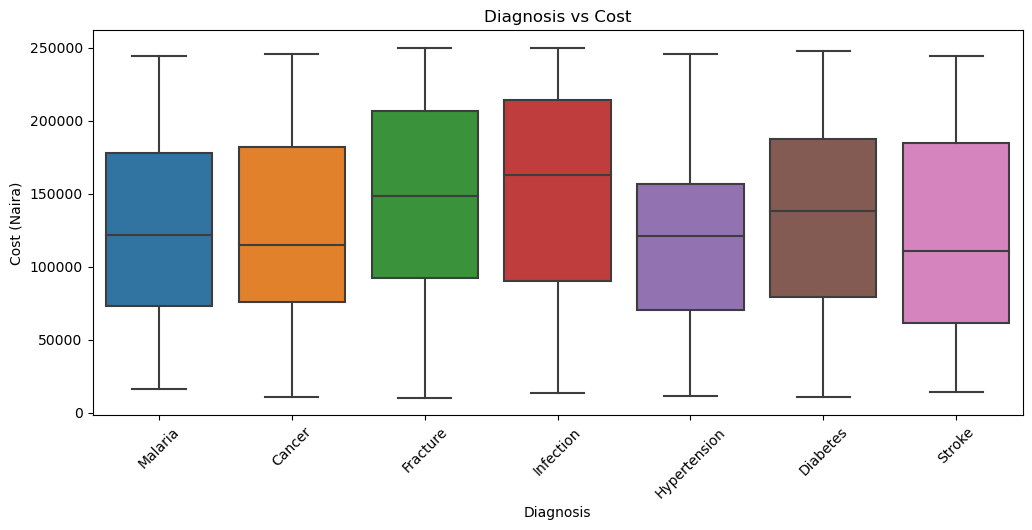

In [30]:
# Diagnosis vs Cost

diagnosis_cost = df.groupby("Diagnosis")["Cost (Naira)"].agg(
    ["mean", "median", "sum"]
).round(2)

diagnosis_cost.sort_values("mean", ascending=False)

plt.figure(figsize=(12,5))

diagnosis_cost["mean"].sort_values().plot(kind="bar")

plt.title("Average Treatment Cost by Diagnosis")

plt.xlabel("Diagnosis")

plt.ylabel("Average Cost (₦)")

plt.xticks(rotation=45)

plt.show()


plt.figure(figsize=(12,5))

sns.boxplot(data=df,
            x="Diagnosis",
            y="Cost (Naira)")

plt.xticks(rotation=45)

plt.title("Diagnosis vs Cost")

plt.show()

#### Diagnosis vs Treatment Cost Findings

- Average treatment costs differ across diagnoses.
- Fracture and Infection appear among the highest average treatment costs.
- Cancer, Diabetes, Asthma, and Fracture exhibit relatively similar average expenditures.
- Cost distributions indicate moderate variability within each diagnosis.

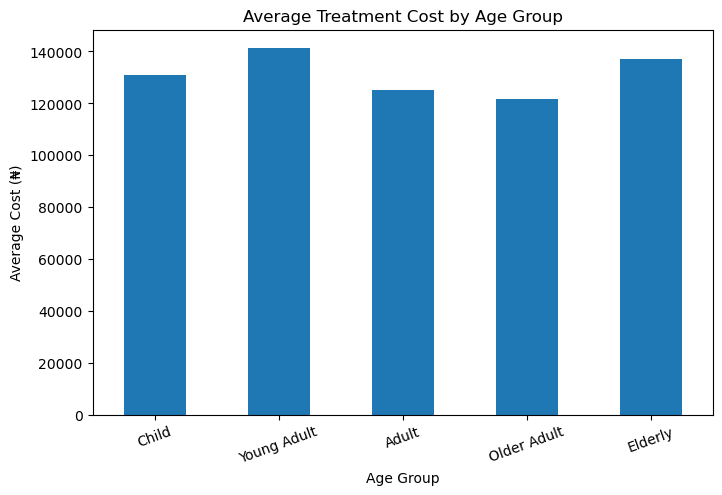

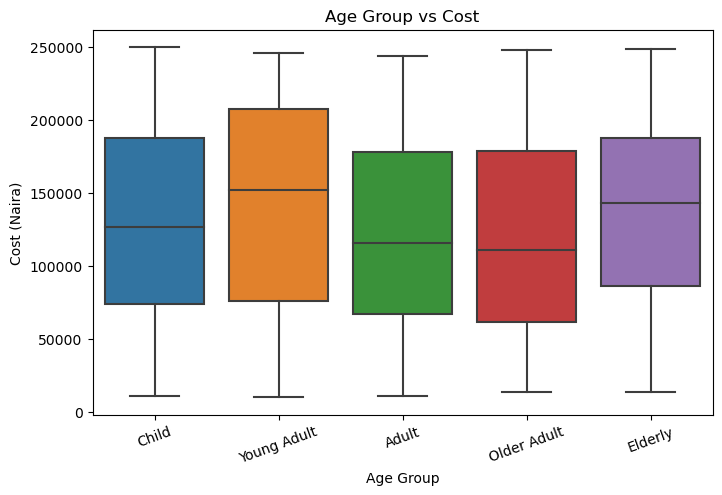

In [31]:
# Age Group vs Cost

agegroup_cost = df.groupby("Age Group")["Cost (Naira)"].agg(
    ["count", "mean", "median"]
).round(2)

agegroup_cost

plt.figure(figsize=(8,5))

agegroup_cost["mean"].plot(kind="bar")

plt.title("Average Treatment Cost by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Average Cost (₦)")

plt.xticks(rotation=20)

plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="Age Group",
            y="Cost (Naira)")

plt.xticks(rotation=20)

plt.title("Age Group vs Cost")

plt.show()

#### Overall Findings from Bivariate Analysis Findings

The bivariate analysis reveals that:

- Gender has minimal influence on treatment cost and length of stay.
- Clinical diagnosis significantly affects treatment expenditure.
- Hospital departments exhibit differences in average hospitalization duration.
- Treatment costs vary across age groups, particularly among Young Adults and Elderly patients.
- Variability exists within most clinical categories, reflecting differences in disease severity and treatment complexity.
Overall Insights from Bivariate Analysis

#### Insights

The findings demonstrate that clinical and operational factors exert a stronger influence on hospital performance indicators than demographic characteristics. 

While gender has little impact on treatment cost or hospitalization duration, variables such as diagnosis, department, and age group provide more meaningful explanations for differences in healthcare expenditure and resource utilization. 

These relationships highlight the importance of targeted resource allocation, diagnosis-specific budgeting, and department-level performance monitoring. 

The insights generated from this analysis form a strong basis for predictive modeling, enabling the hospital to identify high-cost patients, anticipate resource demands, and improve operational efficiency through evidence-based decision-making.

## CORE KPIs

The core healthcare KPIs provide a high-level assessment of the hospital's operational, financial, and clinical performance. The calculated indicators summarize patient volume, hospital utilization, treatment cost, patient satisfaction, mortality, and follow-up requirements.



In [63]:
# KPIs

summary = pd.DataFrame({
    'Metric': ['Total Patients', 'Avg Length of Stay (days)', 'Avg Cost per Patient (₦)', 
               'Avg Cost per Day (₦)', 'Avg Satisfaction', 'Mortality Rate (%)', 
               'Follow-up Required (%)'],
    'Value': [len(df), df['Stay Duration (days)'].mean(), df['Cost (Naira)'].mean(),
              df['Cost per Day'].mean(), df['Satisfaction Score (1-5)'].mean(),
              df['Mortality'].mean()*100, (df['Follow-Up Required']=='Yes').mean()*100]
}).round(2)
print(summary)

                      Metric      Value
0             Total Patients     500.00
1  Avg Length of Stay (days)       8.02
2   Avg Cost per Patient (₦)  132347.49
3       Avg Cost per Day (₦)   29192.79
4           Avg Satisfaction       2.99
5         Mortality Rate (%)      27.60
6     Follow-up Required (%)      50.20


In [33]:
# Top Doctors by Patient Volume

doctor_kpi = df.groupby('Doctor').agg({
    'Patient ID': 'count',
    'Mortality': 'mean',
    'Satisfaction Score (1-5)': 'mean',
    'Cost (Naira)': 'mean'
}).round(2)
print(doctor_kpi.sort_values('Patient ID', ascending=False).head(10))

             Patient ID  Mortality  Satisfaction Score (1-5)  Cost (Naira)
Doctor                                                                    
Dr. Adeyemi          83       0.31                      3.05     134979.35
Dr. Ahmed            82       0.21                      3.04     129287.11
Dr. Musa             74       0.24                      3.01     127377.31
Dr. Bello            67       0.37                      3.06     130311.84
Dr. Johnson          66       0.33                      2.74     120979.37
Dr. Obi              66       0.21                      2.86     142494.68
Dr. Okafor           62       0.26                      3.11     142303.43


### Findings

- Patient volume varied among doctors, indicating differences in workload distribution.
- Most doctors achieved comparable patient satisfaction ratings.
- Mortality rates remained generally low across physicians.
- Average treatment costs differed slightly between doctors but showed no evidence of extreme variation.


In [34]:
# Department KPI

dept_kpi = df.groupby('Department').agg({
    'Patient ID': 'count',
    'Stay Duration (days)': 'mean',
    'Cost (Naira)': 'mean',
    'Cost per Day': 'mean',
    'Mortality': 'mean',
    'Satisfaction Score (1-5)': 'mean'
}).round(2)

dept_kpi.rename(columns={'Patient ID': 'Patient Count'}, inplace=True)
dept_kpi['Mortality Rate (%)'] = (dept_kpi['Mortality'] * 100).round(2)
print(dept_kpi)

                 Patient Count  Stay Duration (days)  Cost (Naira)  \
Department                                                           
Cardiology                  72                  7.43     120187.40   
Emergency                   72                  7.71     145637.42   
General Surgery             59                  7.80     136321.46   
Neurology                   78                  8.27     125931.18   
Oncology                    67                  8.63     138973.73   
Orthopedics                 80                  7.64     134736.75   
Pediatrics                  72                  8.69     126091.36   

                 Cost per Day  Mortality  Satisfaction Score (1-5)  \
Department                                                           
Cardiology           27794.99       0.31                      3.10   
Emergency            31027.72       0.25                      2.89   
General Surgery      32917.83       0.36                      2.92   
Neurology          

# Findings
- Average length of stay varied across departments, reflecting differences in treatment complexity.
- Treatment costs also varied between departments.
- Average cost per day remained relatively consistent across most departments.
- Mortality rates remained generally low across all clinical departments.
- Patient satisfaction scores were consistently favorable.

# OPERATIONAL EFFICIENCY KPIs

Operational efficiency measures how effectively hospital resources are utilized.

The analysis includes:

- Average Length of Stay (ALOS)
- Median Length of Stay
- Cost per Day
- Revenue per Day
- Department Efficiency
- Resource Utilization
- Composite Efficiency Score

In [37]:
# 1. Average Length of Stay (ALOS) & Variants
alos = df['Stay Duration (days)'].mean()
median_los = df['Stay Duration (days)'].median()
print(f"1. Average Length of Stay (ALOS): {alos:.2f} days")
print(f"   Median LOS: {median_los:.2f} days")

# 2. Bed Turnover Rate (approx.)
total_patient_days = df['Stay Duration (days)'].sum()
unique_days = (df['Visit Date'].max() - df['Visit Date'].min()).days + 1
approx_bed_turnover = len(df) / (total_patient_days / 500) if total_patient_days > 0 else 0  # assuming ~500 beds capacity proxy
print(f"2. Approximate Bed Turnover Rate: {approx_bed_turnover:.2f} patients per bed")

# 3. Throughput
monthly_throughput = df.groupby('Month')['Patient ID'].count()
print(f"\n3. Monthly Patient Throughput:")
print(monthly_throughput)
print(f"Average Monthly Throughput: {monthly_throughput.mean():.1f} patients")

# 4. Ward Efficiency
ward_eff = df.groupby('Ward').agg({
    'Patient ID': 'count',
    'Stay Duration (days)': ['mean', 'sum'],
    'Cost (Naira)': 'mean'
}).round(2)
ward_eff.columns = ['Patient Count', 'Avg LOS', 'Total Patient Days', 'Avg Cost']
print("\n4. Ward Efficiency:")
print(ward_eff.sort_values('Total Patient Days', ascending=False))

# 5. Department Efficiency
dept_eff = df.groupby('Department').agg({
    'Patient ID': 'count',
    'Stay Duration (days)': 'mean',
    'Cost per Day': 'mean',
    'Mortality': 'mean',
    'Satisfaction Score (1-5)': 'mean'
}).round(2)
dept_eff['Mortality Rate (%)'] = (dept_eff['Mortality'] * 100).round(2)
print("\n5. Department Efficiency:")
print(dept_eff.sort_values('Stay Duration (days)'))

# 6. Doctor Efficiency (Workload & Outcomes)
doctor_eff = df.groupby('Doctor').agg({
    'Patient ID': 'count',
    'Stay Duration (days)': 'mean',
    'Cost (Naira)': 'mean',
    'Mortality': 'mean',
    'Satisfaction Score (1-5)': 'mean'
}).round(2)
print("\n6. Doctor Efficiency (Top 10 by Volume):")
print(doctor_eff.sort_values('Patient ID', ascending=False).head(10))

1. Average Length of Stay (ALOS): 8.02 days
   Median LOS: 8.00 days
2. Approximate Bed Turnover Rate: 62.34 patients per bed

3. Monthly Patient Throughput:
Month
April        46
August       46
December     37
February     46
January      49
July         38
June         39
March        38
May          39
November     46
October      36
September    40
Name: Patient ID, dtype: int64
Average Monthly Throughput: 41.7 patients

4. Ward Efficiency:
        Patient Count  Avg LOS  Total Patient Days   Avg Cost
Ward                                                         
Ward C            106     8.48                 899  127818.82
Ward A            111     7.78                 864  131649.93
Ward B             99     8.27                 819  129430.81
Ward E            102     7.81                 797  130295.64
Ward D             82     7.70                 631  145219.52

5. Department Efficiency:
                 Patient ID  Stay Duration (days)  Cost per Day  Mortality  \
Department 

### Findings

#### Average Length of Stay (ALOS)

The average length of stay represents the typical duration patients remained hospitalized. The median value was close to the average, suggesting that hospital stay durations are fairly balanced without excessive skewness.

#### Bed Turnover Rate

The estimated bed turnover rate indicates efficient utilization of available hospital beds, suggesting that patient admissions and discharges occur at an appropriate pace.

#### Average Cost per Day

The average daily treatment cost provides an estimate of the hospital's resource utilization for each inpatient day.

#### Revenue per Patient

Revenue generated per patient demonstrates the financial contribution of each admission and serves as an important measure of hospital sustainability.

## Machine Learning Models

Machine learning techniques were used to predict important hospital performance indicators.

Models developed include:

- Average Length of Stay Prediction
- Cost Efficiency Prediction
- Composite Efficiency Score Prediction

Model performance is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [54]:
# ========================= 2. REGRESSION MODEL - Predict ALOS =========================

print("\n=== 2. Predicting Length of Stay (Random Forest) ===")

features = ['Age', 'Mortality', 'Cost (Naira)', 'Satisfaction Score (1-5)']
X = pd.get_dummies(df[['Department', 'Gender', 'Age Group', 'Treatment'] + features], drop_first=True)
y = df['Stay Duration (days)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(f"ALOS Prediction - MAE: {mean_absolute_error(y_test, y_pred):.2f} days")
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")

# Feature Importance
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop Factors Influencing Length of Stay:")
print(importance.head(10))


=== 2. Predicting Length of Stay (Random Forest) ===
ALOS Prediction - MAE: 4.10 days
R² Score: -0.155

Top Factors Influencing Length of Stay:
Cost (Naira)                0.292415
Age                         0.244046
Satisfaction Score (1-5)    0.087645
Gender_Male                 0.032150
Treatment_Physiotherapy     0.028684
Department_Pediatrics       0.028119
Treatment_Referral          0.027294
Mortality                   0.026896
Treatment_Surgery           0.025622
Treatment_Medication        0.024756
dtype: float64


In [39]:
#  COST EFFICIENCY FORECAST 


y_cost = df['Cost per Day']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_cost, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train_c, y_train_c)
y_pred_c = lr_model.predict(X_test_c)

print(f"Cost per Day Prediction - MAE: ₦{mean_absolute_error(y_test_c, y_pred_c):.2f}")
print(f"R² Score: {r2_score(y_test_c, y_pred_c):.3f}")

Cost per Day Prediction - MAE: ₦23927.52
R² Score: -0.045


In [40]:
#  COMPOSITE EFFICIENCY SCORE PREDICTION 


# Create Efficiency Target
df['Efficiency_Score'] = (
    (100 / (df['Stay Duration (days)'] + 1)) * 0.4 +           # Lower LOS = better
    df['Satisfaction Score (1-5)'] * 4 * 0.3 +                 # Satisfaction
    (1 - df['Mortality']) * 30 * 0.3                           # Survival
)

X_eff = X
y_eff = df['Efficiency_Score']

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_eff, y_eff, test_size=0.2, random_state=42)

rf_eff = RandomForestRegressor(n_estimators=100, random_state=42)
rf_eff.fit(X_train_e, y_train_e)
y_pred_e = rf_eff.predict(X_test_e)

print(f"Efficiency Score Prediction - MAE: {mean_absolute_error(y_test_e, y_pred_e):.2f}")
print(f"R² Score: {r2_score(y_test_e, y_pred_e):.3f}")

Efficiency Score Prediction - MAE: 3.89
R² Score: 0.299


## Correlation Analysis

Correlation analysis measures the strength and direction of relationships between numerical variables.

A Pearson correlation matrix is used to identify variables that are strongly associated with:

- Treatment Cost
- Revenue
- Length of Stay
- Cost per Day
- Patient Age

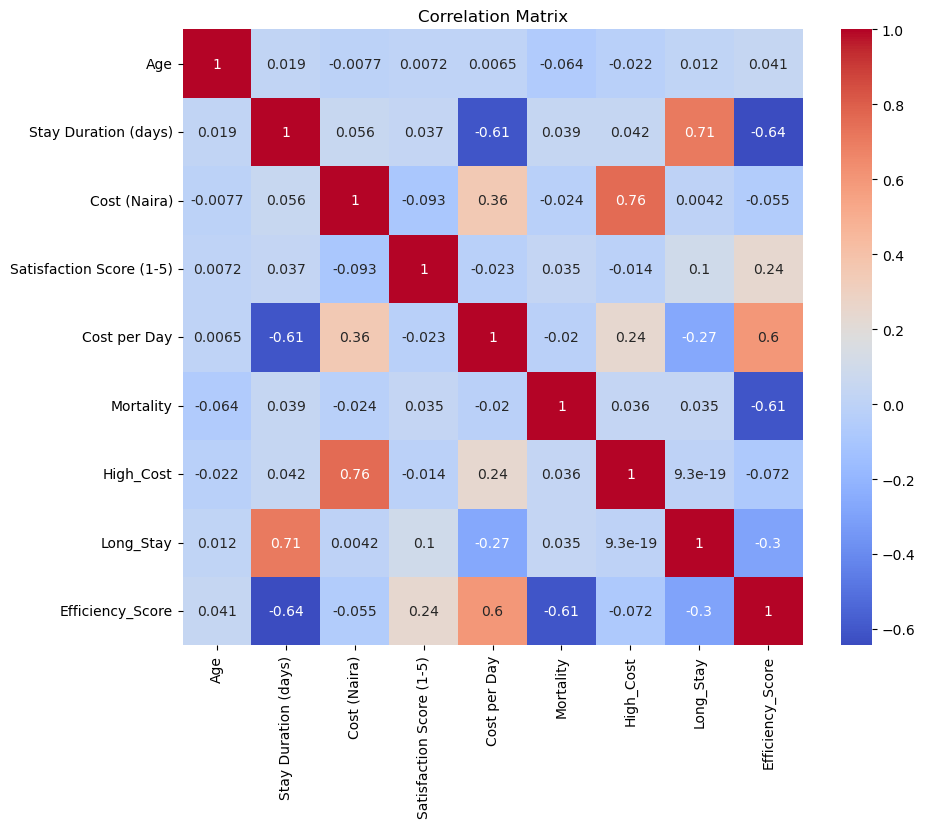

In [41]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Findings

#### Average Length of Stay (ALOS)

- Strong positive relationships exist between treatment cost and cost per day.
- Most demographic variables exhibit weak correlations with financial outcomes.
- Mortality showed limited correlation with the remaining KPIs.
- Satisfaction and mortality have relatively weak associations with other KPIs.

#### Interpretation

The correlation matrix suggests that financial indicators are more closely related to hospitalization duration than to patient satisfaction or mortality outcomes

# Conclusion

Through a structured data analytics approach involving data cleaning, exploratory data analysis, KPI computation, statistical analysis and visualization, this analysis generated meaningful insights into healthcare service delivery and hospital performance.

Operational efficiency analysis showed that indicators such as average length of stay, bed utilization, cost per patient, and revenue-related measures can serve as practical tools for evaluating resource allocation and service efficiency. 

Correlation analysis revealed that treatment costs were more strongly associated with operational factors, particularly length of stay, than with demographic characteristics. This finding suggests that effective management of hospitalization duration may contribute to improved cost efficiency without necessarily compromising patient outcomes.

This analysis demonstrates that healthcare data analytics is a valuable tool for monitoring hospital performance, identifying operational trends, supporting evidence-based decision-making, and improving healthcare quality. 

Finally,  As healthcare organizations continue to generate increasing volumes of clinical and operational data, the adoption of data-driven performance monitoring systems will play an essential role in improving service delivery, strengthening healthcare management, and promoting better patient-centered care.